Ana Paola Loredo Moreno

613772

Doy mi palabra de que he realizado esta actividad con integridad académica.

# Introducción
### Descripción del Problema

El acceso a la seguridad social en México representa uno de los grandes retos del sistema de protección social del país. Existen muchos mexicanos que no tienen apoyo de seguro social. Esta brecha no solo afecta la calidad de vida individual, sino que reproduce ciclos de vulnerabilidad económica y desigualdad estructural.

### Objetivo
El presente proyecto busca predecir si un individuo cuenta o no con acceso a seguridad social a partir de características socioeconómicas, demográficas y de salud disponibles en la Encuesta Nacional de Ingresos y Gastos de los Hogares (ENIGH) mediante los modelos:
- SVM
- Método de ensamble
- Redes neuronales
- LDA
- Regresión logistica

### Fuente De Datos
Los datos provienen de la Encuesta Nacional de Ingresos y Gastos de los Hogares (ENIGH), publicada por el Instituto Nacional de Estadística y Geografía (INEGI). La ENIGH es un instrumento de recolección estadística representativo a nivel nacional que recoge información sobre las condiciones socioeconómicas de los hogares mexicanos, incluyendo ingresos, gastos, características de la vivienda y del hogar, así como condiciones de salud y educación de sus integrantes.



### Variable de Salida

La variable a predecir es **segsoc**, que indica si un individuo tiene acceso a algún esquema de seguridad social. Es una variable binaria (1 = tiene acceso, 0 = no tiene acceso), lo que hace adecuado esta problemática para el uso de modelos de clasificación

Un enfoque de clasificación resulta apropiado porque:
- La variable de salida es cualitativa con dos categorías bien definidas.
- Existe interés en identificar los factores predictivos más importantes.
- Los modelos de clasificación permiten estimar la probabilidad de pertenencia a cada clase, lo cual es útil para la toma de decisiones de política pública.

In [2]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, GridSearchCV #optimizacion de hiperparametros
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.metrics import RocCurveDisplay
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Datos
## Exploración Inicial De Datos

La ENIGH proporciona el diccionario de datos en el siguiente link:
https://www.inegi.org.mx/contenidos/productos/prod_serv/contenidos/espanol/bvinegi/productos/nueva_estruc/889463910626.pdf



### Diccionario de datos de la encuesta de Ingresos

| # | Variable | Tipo | Descripción |
|---|---|---|---|
| 1 | `folioviv` | C(10) | Identificador de la vivienda |
| 2 | `foliohog` | C(1) | Identificador del hogar |
| 3 | `numren` | C(2) | Identificador de la persona |
| 4 | `clave` | C(4) | Clave de ingreso |
| 5 | `mes_1` | C(2) | Primer mes |
| 6 | `mes_2` | C(2) | Segundo mes |
| 7 | `mes_3` | C(2) | Tercer mes |
| 8 | `mes_4` | C(2) | Cuarto mes |
| 9 | `mes_5` | C(2) | Quinto mes |
| 10 | `mes_6` | C(2) | Sexto mes |
| 11 | `ing_1` | N(9) | Ingresos del primer mes |
| 12 | `ing_2` | N(9) | Ingresos del segundo mes |
| 13 | `ing_3` | N(9) | Ingresos del tercer mes |
| 14 | `ing_4` | N(9) | Ingresos del cuarto mes |
| 15 | `ing_5` | N(9) | Ingresos del quinto mes |
| 16 | `ing_6` | N(9) | Ingresos del sexto mes |
| 17 | `ing_tri` | N(12,2) | Ingreso trimestral |
| 18 | `entidad` | C(2) | Entidad federativa |
| 19 | `est_dis` | C(3) | Estrato de diseño muestral |
| 20 | `upm` | C(7) | Unidad Primaria de Muestreo |
| 21 | `factor` | N(5) | Factor de expansión |

In [20]:
ingresos1 = pd.read_csv(
    "ingresos.csv")

ingresos1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397182 entries, 0 to 397181
Data columns (total 21 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   folioviv  397182 non-null  int64  
 1   foliohog  397182 non-null  int64  
 2   numren    397182 non-null  int64  
 3   clave     397182 non-null  object 
 4   mes_1     397182 non-null  object 
 5   mes_2     397182 non-null  object 
 6   mes_3     397182 non-null  object 
 7   mes_4     397182 non-null  object 
 8   mes_5     397182 non-null  object 
 9   mes_6     397182 non-null  object 
 10  ing_1     397182 non-null  int64  
 11  ing_2     397182 non-null  object 
 12  ing_3     397182 non-null  object 
 13  ing_4     397182 non-null  object 
 14  ing_5     397182 non-null  object 
 15  ing_6     397182 non-null  object 
 16  ing_tri   397182 non-null  float64
 17  entidad   397182 non-null  int64  
 18  est_dis   397182 non-null  int64  
 19  upm       397182 non-null  int64  
 20  fact

### Diccionario de datos de la encuesta de población

| # | Variable | Etiqueta | Tipo |
|---|---|---|---|
| 1 | `folioviv` | Identificador de la vivienda | C(1) |
| 2 | `foliohog` | Identificador del hogar | C(1) |
| 3 | `numren` | Identificador de la persona | C(2) |
| 4 | `parentesco` | Parentesco | C(2) |
| 5 | `madre_id` | Identificador de la madre | C(1) |
| 6 | `sexo` | Sexo | C(1) |
| 7 | `edad` | Edad | N(3) |
| 8 | `madre_hog` | Identificador de la madre | C(1) |
| 9 | `madre_id` | Número de renglón de la madre | C(2) |
| 10 | `padre_hog` | Identificador del padre | C(2) |
| 11 | `padre_id` | Número de renglón del padre | C(2) |
| 12 | `disc_ver` | Discapacidad para ver | C(1) |
| 13 | `disc_camin` | Discapacidad para caminar | C(1) |
| 14 | `disc_brazo` | Discapacidad para usar brazos | C(1) |
| 15 | `disc_apren` | Discapacidad para aprender | C(1) |
| 16 | `disc_oir` | Discapacidad para escuchar | C(1) |
| 17 | `disc_vest` | Discapacidad para vestirse | C(1) |
| 18 | `disc_habla` | Discapacidad para hablar | C(1) |
| 19 | `disc_acti` | Discapacidad para realizar actividades diarias | C(1) |
| 20 | `cau_camin` | Causa de discapacidad para caminar | C(1) |
| 21 | `cau_ver` | Causa de discapacidad para ver | C(1) |
| 22 | `cau_brazo` | Causa de discapacidad para usar brazos | C(1) |
| 23 | `cau_oir` | Causa de discapacidad para escuchar | C(1) |
| 24 | `cau_vest` | Causa de discapacidad para vestirse | C(1) |
| 25 | `cau_habla` | Causa de discapacidad para hablar | C(1) |
| 26 | `cau_acti` | Causa de discapacidad para realizar actividades | C(1) |
| 27 | `hablant` | Habla lengua indígena | C(1) |
| 28 | `lenguaint` | Lengua indígena | C(2) |
| 29 | `hlengua` | Habla español | C(1) |
| 30 | `comprenid` | Comprensión | C(1) |
| 31 | `etnia` | Autoadscripción étnica | C(1) |
| 32 | `alfabetism` | Alfabetismo | C(1) |
| 33 | `asis_esc` | Asistencia a la escuela | C(1) |
| 34 | `nivel` | Nivel escolar al que asiste | C(1) |
| 35 | `grado` | Grado escolar al que asiste | C(1) |
| 36 | `tipo_esc` | Tipo de escuela | C(1) |
| 37 | `beca_e` | Beca escolar | C(1) |
| 38 | `otorg_b` | Otorga beca escolar | C(1) |
| 39 | `forma_b` | Forma de beca escolar | C(1) |
| 40 | `cred_e` | Crédito educativo | C(1) |
| 41 | `otorg_c` | Otorga crédito educativo | C(1) |
| 42 | `form_c` | Forma de crédito educativo | C(1) |
| 43 | `nivelaprob` | Nivel de instrucción aprobado | C(1) |
| 44 | `gradoaprob` | Grado aprobado | C(1) |
| 45 | `antec_esc` | Antecedente escolar | C(1) |
| 46 | `residen` | Residencia | C(1) |
| 47 | `edo_conyug` | Estado conyugal | C(1) |
| 48 | `conyug_hog` | Identificador del cónyuge | C(1) |
| 49 | `conyug_id` | Número de renglón del cónyuge | C(2) |
| 50 | `segsoc` | Contribución a la seguridad social | C(1) |
| 51 | `ss_aa` | Tiempo de contribución años | N(2) |
| 52 | `ss_mm` | Tiempo de contribución meses | N(2) |
| 53 | `indice_1` | Pedir ayuda para conseguir trabajo | C(1) |
| 54 | `indice_2` | Pedir ayuda para que lo cuiden | C(1) |
| 55 | `indice_3` | Pedir calidad de dinero urgente | C(1) |
| 56 | `indice_4` | Pedir que lo acompañen al médico | C(1) |
| 57 | `indice_5` | Pedir apoyo para mejoras en su colonia | C(1) |
| 58 | `indice_6` | Pedir que cuiden a los niños | C(1) |
| 59 | `min_1` | Minutos de trabajo | N(2) |
| 60 | `trabajo` | Trabajar | C(1) |
| 61 | `hr_2` | Horas de estudio | N(3) |
| 62 | `min_2` | Minutos de estudio | N(2) |
| 63 | `hr_3` | Horas de estudio | N(3) |
| 64 | `usotiempo2` | Estudiar y hacer actividades | C(1) |
| 65 | `hr_3` | Horas de trabajo comunitario | N(3) |
| 66 | `min_3` | Minutos de trabajo comunitario | N(2) |
| 67 | `usotiempo3` | Trabajo comunitario | C(1) |
| 68 | `nor_4` | Horas de cuidado de otras personas | N(2) |
| 69 | `ion_4` | Horas de cuidado de otras personas | N(2) |
| 70 | `usotiempo4` | Cuidar, atender sin pago | C(1) |
| 71 | `yr_5` | Horas de reparación | N(2) |
| 72 | `ion_5` | Minutos de reparación | N(2) |
| 73 | `usotiempo5` | Reparar su vivienda | C(1) |
| 74 | `yr_6` | Horas dedicadas a quehaceres | N(2) |
| 75 | `ion_6` | Minutos dedicados a quehaceres | N(2) |
| 76 | `yr_7` | Realizar quehaceres en su hogar | C(1) |
| 77 | `yr_7` | Horas de acarreo | N(2) |
| 78 | `ion_7` | Minutos de acarreo | N(2) |
| 79 | `usotiempo7` | Acarrear agua o leña | C(1) |
| 80 | `usotiempo8` | Tiempo para actividades personales | C(1) |
| 81 | `usotiempo_p8` | Tiempo para realizar actividades | C(1) |
| 82 | `pop_insabi` | Población sin acceso INSABI | C(1) |
| 83 | `atemed` | Afiliación para atención médica | C(1) |
| 84 | `inst_1` | Institución médica IMSS | C(1) |
| 85 | `inst_2` | Institución médica ISSSTE | C(1) |
| 86 | `inst_3` | Institución médica ISSSTE estatal | C(1) |
| 87 | `inst_4` | Institución médica PEMEX | C(1) |
| 88 | `inst_5` | Institución médica IMSS/INSABI | C(1) |
| 89 | `inst_6` | Otra institución médica | C(1) |
| 90 | `inst_7` | Población en el trabajo | C(1) |
| 91 | `inscr_1` | Jubilación o invalidez | C(1) |
| 92 | `inscr_2` | Familiar en el hogar | C(1) |
| 93 | `inscr_3` | Mundo del asegurado | C(1) |
| 94 | `inscr_4` | No ser estudiante | C(1) |
| 95 | `inscr_5` | Sin seguro | C(1) |
| 96 | `inscr_6` | Contratación propia | C(1) |
| 97 | `inscr_7` | Algún familiar de otro hogar | C(1) |
| 98 | `inscr_8` | No sabe | C(1) |
| 163 | `razon_19` | El personal dijo que no era necesario | C(2) |
| 164 | `razon_11` | Otra razón de no atención | C(2) |
| 165 | `grav_alta` | Presión alta | C(1) |
| 166 | `diabetes` | Diabetes | C(1) |
| 167 | `seguro_1` | Seguro voluntario SAR, AFORE | C(1) |
| 168 | `seguro_2` | Seguro voluntario de gastos médicos | C(1) |
| 169 | `seguro_3` | Seguro voluntario de vida | C(1) |
| 170 | `seguro_4` | Seguro voluntario de invalidez | C(1) |
| 171 | `seguro_5` | Otro tipo de seguro voluntario | C(1) |
| 172 | `seguro_6` | Ningún tipo de seguro voluntario | C(1) |
| 173 | `seguro_7` | No sabe si tiene seguro | C(1) |
| 174 | `hijos_viv` | Hijos nacidos vivos | N(2) |
| 175 | `hijos_mue` | Hijos fallecidos | N(2) |
| 176 | `hijos_sob` | Hijos sobrevivientes | N(2) |
| 177 | `trabajo_mp` | Trabajó en el mes pasado | C(1) |
| 178 | `motivo_aus` | Motivo de ausencia al trabajo | C(1) |
| 179 | `id_pnea1` | Primera actividad del integrante PNEA | C(1) |
| 180 | `id_pnea2` | Segunda actividad del integrante PNEA | C(1) |
| 181 | `num_trabaj` | Número de trabajos | C(1) |
| 182 | `jub_futuro` | Jóvenes construyendo el futuro | C(1) |
| 183 | `dis_futuro` | Jóvenes construyendo el futuro, código de trabajo | C(1) |
| 184 | `entidad` | Entidad federativa | C(2) |
| 185 | `est_dis` | Estrato de diseño muestral | C(3) |
| 186 | `upm` | Unidad Primaria de Muestreo | C(7) |
| 187 | `factor` | Factor de expansión | N(5) |

In [26]:
columns = poblacion1.columns.tolist()
num_columns_per_line = 5 # You can adjust this number

print("Columnas de poblacion1:")
for i in range(0, len(columns), num_columns_per_line):
    print(", ".join(columns[i:i + num_columns_per_line]))

Columnas de poblacion1:
folioviv, foliohog, numren, parentesco, sexo
edad, madre_hog, madre_id, padre_hog, padre_id
disc_camin, disc_ver, disc_brazo, disc_apren, disc_oir
disc_vest, disc_habla, disc_acti, cau_camin, cau_ver
cau_brazo, cau_apren, cau_oir, cau_vest, cau_habla
cau_acti, hablaind, lenguaind, hablaesp, comprenind
etnia, alfabetism, asis_esc, nivel, grado
tipoesc, tiene_b, otorg_b, forma_b, tiene_c
otorg_c, forma_c, nivelaprob, gradoaprob, antec_esc
residencia, edo_conyug, pareja_hog, conyuge_id, segsoc
ss_aa, ss_mm, redsoc_1, redsoc_2, redsoc_3
redsoc_4, redsoc_5, redsoc_6, hor_1, min_1
usotiempo1, hor_2, min_2, usotiempo2, hor_3
min_3, usotiempo3, hor_4, min_4, usotiempo4
hor_5, min_5, usotiempo5, hor_6, min_6
usotiempo6, hor_7, min_7, usotiempo7, hor_8
min_8, usotiempo8, pop_insabi, atemed, inst_1
inst_2, inst_3, inst_4, inst_5, inst_6
inscr_1, inscr_2, inscr_3, inscr_4, inscr_5
inscr_6, inscr_7, inscr_8, prob_anio, prob_mes
prob_sal, aten_sal, servmed_1, servmed_2, servm

Varias columnas del dataset original presentan un porcentaje muy alto de valores en blanco, lo cual es una característica estructural de la ENIGH.  Muchas preguntas son condicionales, es decir, solo se responden si la persona cumple cierto criterio previo.Se eliminaron las columnas que superan la mitad de valores faltantes, ya que su información es demasiado escasa para aportar poder predictivo al modelo.


In [34]:
print("Valores en blanco o espacios por columna:")
i = 0
for col in poblacion1.columns:
    blancos = (poblacion1[col].astype(str).str.strip() == '').sum()
    if blancos > 0:
        i+=1
        print(f"{i}  {col}: {blancos} valores vacíos")

for col in ['segsoc', 'trabajo_mp', 'nivelaprob', 'edo_conyug', 'alfabetism']:
    print(f"\n{col} — valores únicos:")
    print(poblacion1[col].value_counts(dropna=False).head(10))


Valores en blanco o espacios por columna:
1  madre_id: 172170 valores vacíos
2  padre_id: 211002 valores vacíos
3  cau_camin: 282619 valores vacíos
4  cau_ver: 284867 valores vacíos
5  cau_brazo: 298326 valores vacíos
6  cau_apren: 295753 valores vacíos
7  cau_oir: 297510 valores vacíos
8  cau_vest: 302555 valores vacíos
9  cau_habla: 303215 valores vacíos
10  cau_acti: 301584 valores vacíos
11  hablaind: 11472 valores vacíos
12  lenguaind: 289388 valores vacíos
13  hablaesp: 289388 valores vacíos
14  comprenind: 31768 valores vacíos
15  etnia: 11472 valores vacíos
16  alfabetism: 11472 valores vacíos
17  asis_esc: 11472 valores vacíos
18  nivel: 224672 valores vacíos
19  grado: 224675 valores vacíos
20  tipoesc: 224672 valores vacíos
21  tiene_b: 224672 valores vacíos
22  otorg_b: 289571 valores vacíos
23  forma_b: 289571 valores vacíos
24  tiene_c: 283985 valores vacíos
25  otorg_c: 309462 valores vacíos
26  forma_c: 309462 valores vacíos
27  nivelaprob: 11472 valores vacíos
28  grad

# 2.2 Preparación y tratamiento de los datos

Se trabajó con dos archivos de la ENIGH: poblacion.csv e ingresos.csv. Primeramente, se lee el archivo de ingresos.csv y solo se ocupan las columnas de "'folioviv','foliohog','numren','ing_tri", que son identificadores más el ingreso. Los identificadores por persona se requieren para conectar los datos por persona a su ingreso.

Siguiente, se lee el archivo de 'poblacion.csv' en el que se filtra la población a personas en edad laboral (18–65 años), que es la población relevante para analizar el acceso a seguridad social. Para las variables de discapacidad, se construyó como variable binaria a partir de ocho variables individuales (disc_camin, disc_ver, etc.), donde 1 indica tener al menos una dificultad funcional en niveles 2 o 3. Conservar 8 variables con valores nulos y con alta interacciones crearía mucho ruido. Se creó educacion_total como aproximación continua combinando nivelaprob y gradoaprob que tienen alta correlación. Se derivó también alfabetizado como binaria desde alfabetism. Las variables diabetes, pres_alta, segsoc y pop_insabi se convirtieron a 0/1 (1 = condición presente). asis_esc y trabajo_mp también se recodificaron a 0/1. Las recodificaciones ayudan a qué los modelos interpreten correctamente. Se transformó en variables dummy (conyug_2 a conyug_6) eliminando la categoría de referencia para evitar multicolinealidad.

Los ingresos trimestrales (ing_tri) de ingresos.csv se sumaron por persona usando los folios como llave, y se unieron a la tabla de población con un LEFT JOIN. Las personas sin registro de ingreso se asignaron con valor 0. Se utiliza un left join para priorizar conectar a todas las personas que tengan un ingreso.

 Se eliminaron todas las filas con al menos un valor nulo, resultando en un dataset limpio de aproximadamente 100,000 observaciones sin valores faltantes en ninguna variable para evitar errores que lancen los modelos en su construcción .


In [9]:
## CODIGO GENERADO CON APOYO DE IA GENERATIVA

import pandas as pd
import numpy as np

# ============================================================
# 1️⃣ LEER INGRESOS (archivo ingresos.csv)
# ============================================================

print("Leyendo ingresos...")

ingresos = pd.read_csv(
    "ingresos.csv",
    usecols=['folioviv','foliohog','numren','ing_tri'],
    low_memory=False
)

# Convertir ingreso a número
ingresos['ing_tri'] = pd.to_numeric(ingresos['ing_tri'], errors='coerce')

# Quitar valores inválidos
ingresos = ingresos.dropna(subset=['ing_tri'])
ingresos = ingresos[ingresos['ing_tri'].notna()]

print("Filas de ingresos válidos:", ingresos.shape)


# ============================================================
# 2️⃣ COLAPSAR INGRESOS A NIVEL PERSONA
# (aquí ocurre la magia real de ENIGH)
# ============================================================

print("Agrupando ingresos por persona...")

ingresos_persona = (
    ingresos
    .groupby(['folioviv','foliohog','numren'], as_index=False)
    .agg(ingreso_total=('ing_tri','sum'))
)

print("Personas con ingreso:", ingresos_persona.shape)


# ============================================================
# 3️⃣ LEER POBLACIÓN
# ============================================================


import pandas as pd

print("Leyendo población...")

cols_disc = [
    "disc_camin","disc_ver","disc_brazo","disc_apren",
    "disc_oir","disc_vest","disc_habla","disc_acti"
]

poblacion = pd.read_csv(
    "poblacion.csv",
    usecols=[
       'folioviv','asis_esc','trabajo_mp','parentesco','foliohog','trabajo_mp','numren','edad','sexo','nivelaprob','gradoaprob','alfabetism','edo_conyug','hijos_viv','diabetes','pres_alta','segsoc','pop_insabi','entidad',*cols_disc
    ],
    low_memory=False
)

print("Personas en población:", poblacion.shape)

poblacion[cols_disc] = poblacion[cols_disc].replace(5, pd.NA)

# Asegurar que sean numéricas
poblacion[cols_disc] = poblacion[cols_disc].apply(pd.to_numeric, errors='coerce')

# Discapacidad = tener al menos UNA dificultad (niveles 2,3 o 4)
poblacion["Discapacidad"] = poblacion[cols_disc].apply(
    lambda row: row.isin([2, 3]).any(),
    axis=1
).astype(int)

##print("\nDistribución real de discapacidad:")
##print(poblacion["Discapacidad"].value_counts())

##print("\nEjemplo de frecuencias por variable:")
##for c in cols_disc:
 ##   print("\n", c)
  ##  print(poblacion[c].value_counts(dropna=False))

# ============================================================
# 4️⃣ FILTRAR EDAD LABORAL
# ============================================================

poblacion = poblacion[(poblacion['edad'] >= 18) & (poblacion['edad'] <= 65)]

print("Personas 18–65:", poblacion.shape)


# ============================================================
# 6️⃣ NOS QUEDAMOS SOLO CON VARIABLES NECESARIAS
# ============================================================

poblacion = poblacion[
    [
       'folioviv','asis_esc','parentesco','foliohog','trabajo_mp','numren','edad','sexo','nivelaprob','gradoaprob','alfabetism','edo_conyug','hijos_viv','diabetes','pres_alta','segsoc','pop_insabi','entidad','Discapacidad'
    ]
]

# ============================================================
# 7️⃣ MERGE CORRECTO (AHORA SÍ 1 A 1 REAL)
# ============================================================

print("Uniendo población con ingresos...")

df_final = poblacion.merge(
    ingresos_persona,
    on=['folioviv','foliohog','numren'],
    how='left'
)

df_final['ingreso_total'] = df_final['ingreso_total'].fillna(0)


print("Base final:", df_final.shape)


# ============================================================
# 8️⃣ TRANSFORMACIÓN PARA REGRESIÓN
# ============================================================

df_modelo = df_final.copy()

df_modelo['log_ingreso'] = np.log1p(df_modelo['ingreso_total'])

# Experiencia potencial tipo Mincer
df_modelo['edad2'] = df_modelo['edad']**2

df_modelo = pd.get_dummies(
    df_modelo,
    columns=[
        'edo_conyug','segsoc','entidad'
    ],
    drop_first=True
)

# ============================================================
# 9️⃣ GUARDAR BASE FINAL
# ============================================================

print("Archivo creado: base_enigh_modelo.csv")

cols_str = [
    'nivelaprob','gradoaprob','hijos_viv',
    'diabetes','pres_alta','segsoc','pop_insabi','alfabetism','asis_esc'
]

df_final[cols_str] = df_final[cols_str].replace(r'^\s*$', np.nan, regex=True)

for c in cols_str:
    df_final[c] = pd.to_numeric(df_final[c], errors='coerce')

df_final['hijos_viv'] = df_final['hijos_viv'].fillna(0)


df_final['diabetes']   = (df_final['diabetes'] == 1).astype(int)
df_final['pres_alta']  = (df_final['pres_alta'] == 1).astype(int)


df_final['segsoc'] = (df_final['segsoc'] == 1).astype(int)

df_final['pop_insabi'] = (df_final['pop_insabi'] == 1).astype(int)

df_final['nivelaprob'] = df_final['nivelaprob'].fillna(0)
df_final['gradoaprob'] = df_final['gradoaprob'].fillna(0)

df_final['nivelaprob'] = df_final['nivelaprob'].fillna(0)
df_final['gradoaprob'] = df_final['gradoaprob'].fillna(0)

### transformación de nivelaprob y gradoaprob
df_final['educacion_total'] = df_final['nivelaprob'] * 3 + df_final['gradoaprob']

df_final['alfabetism'] = df_final['alfabetism'].replace(' ', np.nan)
df_final['alfabetism'] = pd.to_numeric(df_final['alfabetism'], errors='coerce')

# Crear variable binaria interpretable
df_final['alfabetizado'] = (df_final['alfabetism'] == 1).astype(int)

df_final['edo_conyug'] = df_final['edo_conyug'].replace(' ', np.nan)
df_final['edo_conyug'] = pd.to_numeric(df_final['edo_conyug'], errors='coerce')

df_final = pd.get_dummies(
    df_final,
    columns=['edo_conyug'],
    prefix='conyug',
    drop_first=True
)

df_final['asis_esc'] = df_final['asis_esc'].replace(' ', np.nan)
df_final['asis_esc'] = pd.to_numeric(df_final['asis_esc'], errors='coerce')
df_final['asis_esc'] = df_final['asis_esc'].map({1:1, 2:0})

df_final['trabajo_mp'] = df_final['trabajo_mp'].replace(' ', np.nan)
df_final['trabajo_mp'] = pd.to_numeric(df_final['trabajo_mp'], errors='coerce')
df_final['trabajo_mp'] = df_final['trabajo_mp'].map({1:1, 2:0})

Leyendo ingresos...
Filas de ingresos válidos: (397182, 4)
Agrupando ingresos por persona...
Personas con ingreso: (205144, 4)
Leyendo población...
Personas en población: (309684, 26)
Personas 18–65: (190245, 27)
Uniendo población con ingresos...
Base final: (190245, 20)
Archivo creado: base_enigh_modelo.csv


Reparo de datos faltantes en 'trabajo_mp', se eliminan las que tienen datos faltantes.

In [10]:
print(df_final.isnull().sum())

folioviv             0
asis_esc             0
parentesco           0
foliohog             0
trabajo_mp         130
numren               0
edad                 0
sexo                 0
nivelaprob           0
gradoaprob           0
alfabetism           0
hijos_viv            0
diabetes             0
pres_alta            0
segsoc               0
pop_insabi           0
entidad              0
Discapacidad         0
ingreso_total        0
educacion_total      0
alfabetizado         0
conyug_2             0
conyug_3             0
conyug_4             0
conyug_5             0
conyug_6             0
dtype: int64


In [11]:
print(f"Filas antes de eliminar nulos: {df_final.shape[0]}")
df_final = df_final.dropna().copy()
print(f"Filas después de eliminar nulos: {df_final.shape[0]}")
print("\nVerificación de nulos después de la eliminación:")
print(df_final.isnull().sum())

Filas antes de eliminar nulos: 190245
Filas después de eliminar nulos: 190115

Verificación de nulos después de la eliminación:
folioviv           0
asis_esc           0
parentesco         0
foliohog           0
trabajo_mp         0
numren             0
edad               0
sexo               0
nivelaprob         0
gradoaprob         0
alfabetism         0
hijos_viv          0
diabetes           0
pres_alta          0
segsoc             0
pop_insabi         0
entidad            0
Discapacidad       0
ingreso_total      0
educacion_total    0
alfabetizado       0
conyug_2           0
conyug_3           0
conyug_4           0
conyug_5           0
conyug_6           0
dtype: int64


In [12]:
# ── 6. División entrenamiento / prueba (80/20, estratificada) ─────────────────
X = df_final.drop(columns=['segsoc','foliohog','folioviv'])
y = df_final['segsoc']

# Convert boolean columns to integer (0 or 1) to prevent potential NaN interpretation by some models
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # mantiene proporción de clases en ambas particiones
)

print(f"\nTamaño entrenamiento: {X_train.shape[0]} registros")
print(f"Tamaño prueba:        {X_test.shape[0]} registros")

# ── 7. Escalado de features ───────────────────────────────────────────────────
# Necesario para SVM y Red Neuronal; no afecta a Random Forest ni Boosting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit SOLO en entrenamiento
X_test_scaled  = scaler.transform(X_test)         # transform en prueba

print("Variables listas!")


Tamaño entrenamiento: 152092 registros
Tamaño prueba:        38023 registros
Variables listas!


/tmp/ipykernel_21615/2643389968.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Blues')


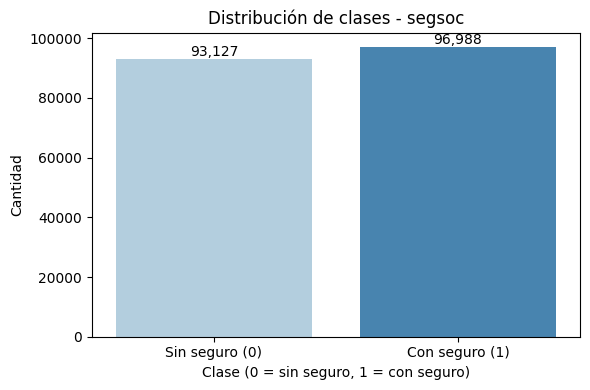

In [13]:
df_final["segsoc"].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Blues')
plt.title('Distribución de clases - segsoc')
plt.xlabel('Clase (0 = sin seguro, 1 = con seguro)')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['Sin seguro (0)', 'Con seguro (1)'])
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height()):,}',
                       (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Construcción y comparación de modelos

## Metodología de construcción:
### 1. Balanceo de clases
### 2. Separación de datos de entrenamiento y prueba  
### 3. Construcción de modelos con pruebas de parametros (si aplica) Logistica, LDA, Boosting, SVM y Redes Neuronales


=== Proporción de clases ===
        Original  Train (80%)  Test (20%)
segsoc                                   
0         0.4898       0.4898      0.4898
1         0.5102       0.5102      0.5102

=== Conteos absolutos ===
        Train (80%)  Test (20%)
segsoc                         
0             74502       18625
1             77590       19398


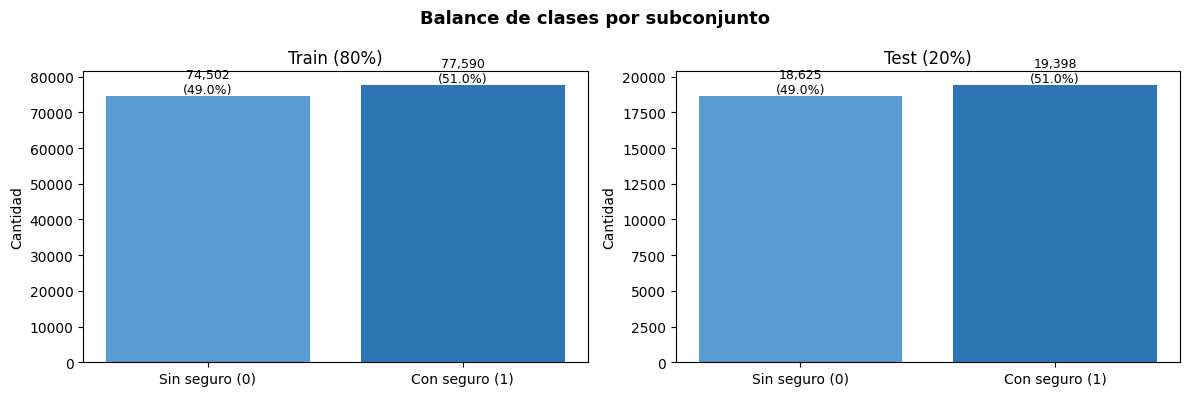

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def class_dist(data, label):
    counts = pd.Series(data).value_counts(normalize=True).sort_index()
    return counts

orig = class_dist(y, 'Original')
train = class_dist(y_train, 'Train')
test = class_dist(y_test, 'Test')

dist_df = pd.DataFrame({
    'Original': orig,
    'Train (80%)': train,
    'Test (20%)': test
})

print("=== Proporción de clases ===")
print(dist_df.round(4))
print()
print("=== Conteos absolutos ===")
print(pd.DataFrame({
   ## 'Original': pd.Series(y).value_counts().sort_index(),
    'Train (80%)': pd.Series(y_train).value_counts().sort_index(),
    'Test (20%)': pd.Series(y_test).value_counts().sort_index()
}))

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
datasets = {'Train (80%)': y_train, 'Test (20%)': y_test}

for ax, (title, data) in zip(axes, datasets.items()):
    counts = pd.Series(data).value_counts().sort_index()
    bars = ax.bar(['Sin seguro (0)', 'Con seguro (1)'], counts, color=['#5B9BD5', '#2E75B6'])
    ax.set_title(title)
    ax.set_ylabel('Cantidad')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{count:,}\n({count/len(data):.1%})', ha='center', va='bottom', fontsize=9)

plt.suptitle('Balance de clases por subconjunto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Regresión Logística
La regresión logística es un modelo lineal que estima la probabilidad de pertenencia a cada clase mediante la función sigmoide. Es utilizado con frecuencia por su interpretabilidad y eficiencia computacional. Es sensible a la escala de las variables, por lo que se utilizan los datos estandarizados.
Se entrenaron 3 modelos de regresión logistica con distintos parámetros y se eligió el modelo con mejor accuracy.

En este caso se selecciono el segundo modelo con accuracy de 0.71625 con parámetros de LogisticRegression(C=0.1, max_iter=1000, random_state=42).

In [13]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(
    LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced'),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Resultados Validación Cruzada (5-fold) con desviación estándar:\n")
for metric in scoring:
    mean_score = np.mean(cv_results[f'test_{metric}'])
    std_score = np.std(cv_results[f'test_{metric}'])
    print(f"{metric.upper()}: {mean_score:.4f} (+/- {std_score:.4f})")

Resultados Validación Cruzada (5-fold) con desviación estándar:

ACCURACY: 0.7185 (+/- 0.0014)
PRECISION: 0.7289 (+/- 0.0009)
RECALL: 0.7136 (+/- 0.0039)
F1: 0.7212 (+/- 0.0020)
ROC_AUC: 0.7880 (+/- 0.0011)


Accuracy: 0.7160139915314415
              precision    recall  f1-score   support

           0       0.70      0.72      0.71     18625
           1       0.73      0.71      0.72     19398

    accuracy                           0.72     38023
   macro avg       0.72      0.72      0.72     38023
weighted avg       0.72      0.72      0.72     38023



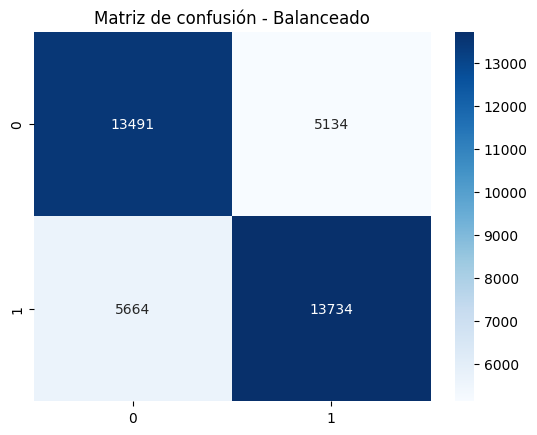

/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: max_iter. After release 0.14, this will raise.
  warnings.warn(


Optimization terminated successfully.
         Current function value: 0.563820
         Iterations 7
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: y                Pseudo R-squared: 0.186      
Date:               2026-03-25 05:13 AIC:              171548.9950
No. Observations:   152092           BIC:              171767.5043
Df Model:           21               Log-Likelihood:   -85752.    
Df Residuals:       152070           LL-Null:          -1.0539e+05
Converged:          1.0000           LLR p-value:      0.0000     
No. Iterations:     7.0000           Scale:            1.0000     
------------------------------------------------------------------
       Coef.    Std.Err.     z     P>|z|     [0.025       0.975]  
------------------------------------------------------------------
const  0.0819      0.0059  13.9879 0.0000       0.0704      0.0933
x1    -0.3108      0.0058 -53.3442 0.0000      -0.322

In [16]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


# 4. Modelo balanceado (sklearn)
logreg = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - Balanceado')
plt.show()

# 5. Summary con statsmodels — ahora con nombres
x_train_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train.values, x_train_sm)
result = logit_model.fit(max_iter=1000)
print(result.summary2())



Accuracy: 0.7162506903716171
              precision    recall  f1-score   support

           0       0.71      0.71      0.71     18625
           1       0.72      0.72      0.72     19398

    accuracy                           0.72     38023
   macro avg       0.72      0.72      0.72     38023
weighted avg       0.72      0.72      0.72     38023



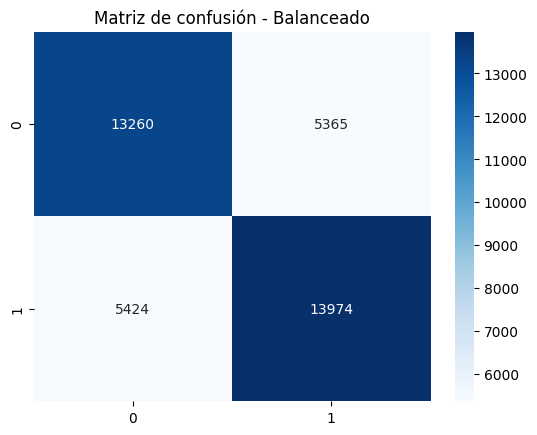

/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: max_iter. After release 0.14, this will raise.
  warnings.warn(


Optimization terminated successfully.
         Current function value: 0.563820
         Iterations 7
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: y                Pseudo R-squared: 0.186      
Date:               2026-03-25 17:30 AIC:              171548.9950
No. Observations:   152092           BIC:              171767.5043
Df Model:           21               Log-Likelihood:   -85752.    
Df Residuals:       152070           LL-Null:          -1.0539e+05
Converged:          1.0000           LLR p-value:      0.0000     
No. Iterations:     7.0000           Scale:            1.0000     
------------------------------------------------------------------
       Coef.    Std.Err.     z     P>|z|     [0.025       0.975]  
------------------------------------------------------------------
const  0.0819      0.0059  13.9879 0.0000       0.0704      0.0933
x1    -0.3108      0.0058 -53.3442 0.0000      -0.322

In [17]:
from sklearn.linear_model import LogisticRegression

logreg_v2 = LogisticRegression(C=0.1, max_iter=1000, random_state=42)

logreg_v2.fit(X_train_scaled, y_train)

y_pred = logreg_v2.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - Balanceado')
plt.show()

# 5. Summary con statsmodels — ahora con nombres
x_train_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train.values, x_train_sm)
result = logit_model.fit(max_iter=1000)
print(result.summary2())


Accuracy: 0.7162769902427478
              precision    recall  f1-score   support

           0       0.71      0.71      0.71     18625
           1       0.72      0.72      0.72     19398

    accuracy                           0.72     38023
   macro avg       0.72      0.72      0.72     38023
weighted avg       0.72      0.72      0.72     38023



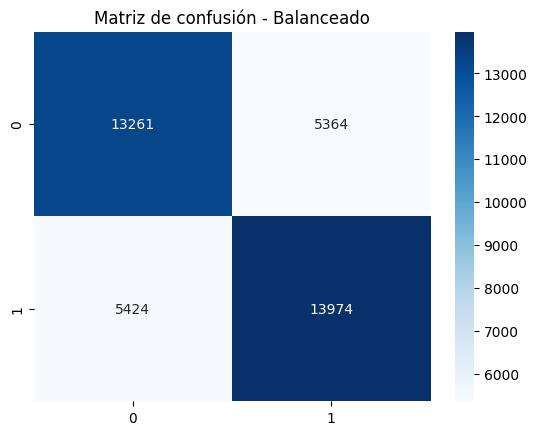

/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: max_iter. After release 0.14, this will raise.
  warnings.warn(


Optimization terminated successfully.
         Current function value: 0.563820
         Iterations 7
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: y                Pseudo R-squared: 0.186      
Date:               2026-03-25 17:31 AIC:              171548.9950
No. Observations:   152092           BIC:              171767.5043
Df Model:           21               Log-Likelihood:   -85752.    
Df Residuals:       152070           LL-Null:          -1.0539e+05
Converged:          1.0000           LLR p-value:      0.0000     
No. Iterations:     7.0000           Scale:            1.0000     
------------------------------------------------------------------
       Coef.    Std.Err.     z     P>|z|     [0.025       0.975]  
------------------------------------------------------------------
const  0.0819      0.0059  13.9879 0.0000       0.0704      0.0933
x1    -0.3108      0.0058 -53.3442 0.0000      -0.322

In [18]:
logreg_v3 = LogisticRegression(C=10.0, max_iter=1000, random_state=42)

logreg_v3.fit(X_train_scaled, y_train)

y_pred = logreg_v3.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - Balanceado')
plt.show()

# 5. Summary con statsmodels — ahora con nombres
x_train_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train.values, x_train_sm)
result = logit_model.fit(max_iter=1000)
print(result.summary2())



## LDA
LDA busca la proyección lineal que mejor separa las clases, asumiendo que las variables siguen una distribución normal multivariada con igual matriz de covarianza entre clases. Ofrece un balance entre sencillez interpretativa y capacidad discriminatoria, y también se beneficia de los datos estandarizados.

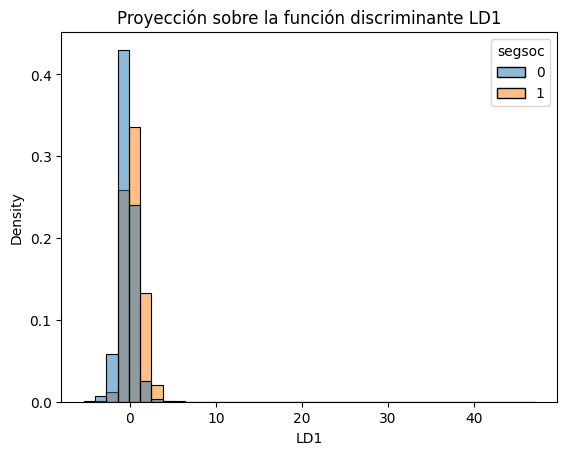

Accuracy LDA: 0.6392446677011283
              precision    recall  f1-score   support

           0       0.62      0.66      0.64     18625
           1       0.66      0.62      0.64     19398

    accuracy                           0.64     38023
   macro avg       0.64      0.64      0.64     38023
weighted avg       0.64      0.64      0.64     38023



In [39]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# Variables coherentes con LDA
cols_lda = ['edad', 'ingreso_total', 'educacion_total', 'hijos_viv']

# Get the indices of the LDA features from the global X DataFrame
lda_feature_indices = [X.columns.get_loc(col) for col in cols_lda]

# Select the LDA features from the globally scaled training and test sets
X_train_lda_features_scaled = X_train_scaled[:, lda_feature_indices]
X_test_lda_features_scaled = X_test_scaled[:, lda_feature_indices]

# Modelo LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_lda_features_scaled, y_train)

# Proyección sobre LD1 (for visualization)
X_train_lda = lda.transform(X_train_lda_features_scaled)

# Make predictions for the classification report, using the correctly prepared test set
y_pred_lda = lda.predict(X_test_lda_features_scaled)

# Visualización
plt.figure()
sns.histplot(x=X_train_lda[:,0], hue=y_train, bins=40, stat='density', common_norm=False)
plt.title("Proyección sobre la función discriminante LD1")
plt.xlabel("LD1")
plt.show()

print("Accuracy LDA:", accuracy_score(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

In [39]:
data_for_cov = pd.concat([X, y], axis=1)
cov_matrix = np.cov(data_for_cov.values, rowvar=False)

# Get column names for better readability
columns = X.columns.tolist() + ['segsoc']
cov_df = pd.DataFrame(cov_matrix, index=columns, columns=columns)



## Métodos De Ensamble
Boosting construye múltiples árboles de decisión durante el entrenamiento y combina los árboles mediante una suma ponderada de sus predicciones. Al agregar múltiples modelos débiles, reduce el sesgo y generalmente ofrece muy buena precisión. Adicionalmente, permite obtener la importancia de cada variable predictora. No requiere estandarización. Se utilizó el modelo que obtuvo el accuracy más alto con 0.761.

ingreso_total: 0.5813
entidad: 0.1121
nivelaprob: 0.0800
edad: 0.0776
educacion_total: 0.0425
pop_insabi: 0.0342
pres_alta: 0.0191
hijos_viv: 0.0146
diabetes: 0.0101
sexo: 0.0070
trabajo_mp: 0.0050
asis_esc: 0.0030
conyug_6: 0.0028
conyug_2: 0.0022
alfabetism: 0.0018
parentesco: 0.0014
conyug_3: 0.0012
conyug_4: 0.0012
alfabetizado: 0.0011
numren: 0.0010
Discapacidad: 0.0006
gradoaprob: 0.0001
conyug_5: 0.0001


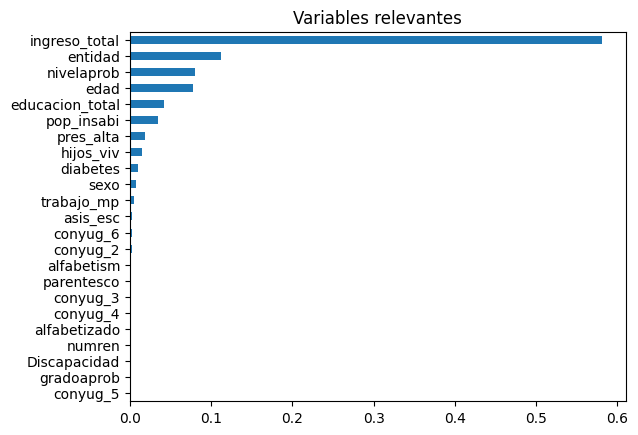

Accuracy de Boosting: 0.7606974725823843
F1-score de Boosting: 0.7605461007950824
              precision    recall  f1-score   support

           0       0.76      0.75      0.75     18625
           1       0.76      0.77      0.77     19398

    accuracy                           0.76     38023
   macro avg       0.76      0.76      0.76     38023
weighted avg       0.76      0.76      0.76     38023



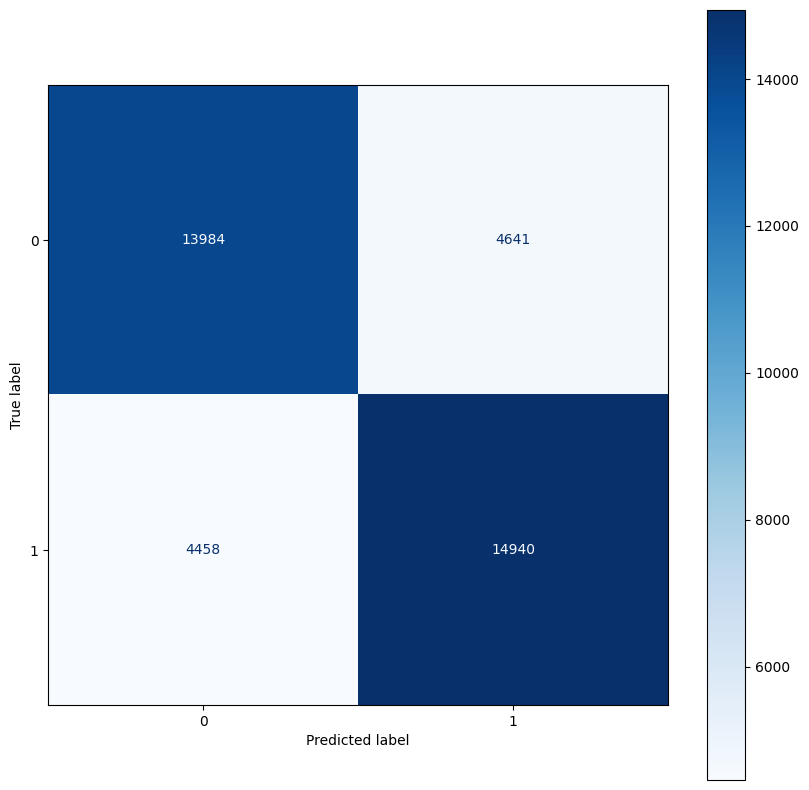

In [28]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

boost = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
).fit(X_train, y_train)

ind = boost.feature_importances_.argsort()[::-1]
for index in ind:
    print(f'{X_test.columns[index]}: {boost.feature_importances_[index]:.4f}')

importancias = boost.feature_importances_
importancias_df = pd.Series(importancias, index=X_test.columns)
importancias_df = importancias_df[importancias_df > 0].sort_values()

plt.figure()
importancias_df.plot(kind="barh")
plt.title("Variables relevantes")
plt.show()

predBoost = boost.predict(X_test)
accBoost = accuracy_score(y_test, predBoost)
f1Boost = f1_score(y_test, predBoost, average="macro")
print("Accuracy de Boosting:", accBoost)
print("F1-score de Boosting:", f1Boost)
print(classification_report(y_test, predBoost))

disp = ConfusionMatrixDisplay.from_predictions(y_test, predBoost, cmap=plt.cm.Blues)
fig = disp.ax_.get_figure()
fig.set_figwidth(10)
fig.set_figheight(10)
plt.show()

Accuracy de Boosting: 0.7613023696183888
F1-score de Boosting: 0.7611729866144938
              precision    recall  f1-score   support

           0       0.76      0.75      0.76     18625
           1       0.76      0.77      0.77     19398

    accuracy                           0.76     38023
   macro avg       0.76      0.76      0.76     38023
weighted avg       0.76      0.76      0.76     38023



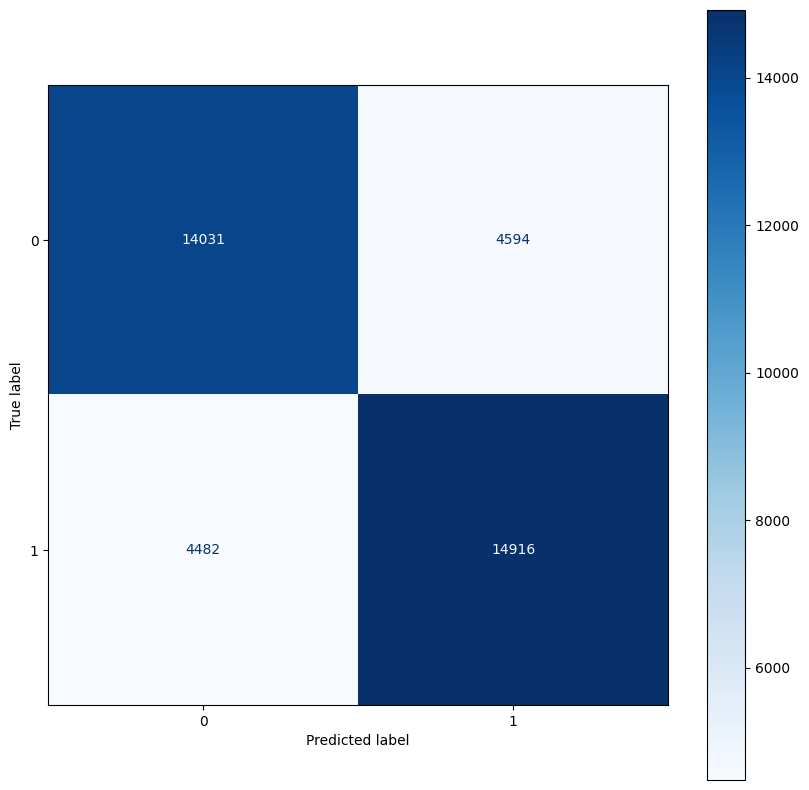

In [31]:

# Prueba estos dos y quédate con el mejor AUC
boost_v2 = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42).fit(X_train, y_train)

predBoost = boost_v2.predict(X_test)
accBoost = accuracy_score(y_test, predBoost)
f1Boost = f1_score(y_test, predBoost, average="macro")
print("Accuracy de Boosting:", accBoost)
print("F1-score de Boosting:", f1Boost)
print(classification_report(y_test, predBoost))

disp = ConfusionMatrixDisplay.from_predictions(y_test, predBoost, cmap=plt.cm.Blues)
fig = disp.ax_.get_figure()
fig.set_figwidth(10)
fig.set_figheight(10)
plt.show()

In [29]:

boost_v3 = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=4, random_state=42).fit(X_train, y_train)

predBoost3 = boost_v3.predict(X_test)
accBoost3 = accuracy_score(y_test, predBoost3)
f1Boost3 = f1_score(y_test, predBoost3, average="macro")
print("Accuracy de Boosting:", accBoost3)
print("F1-score de Boosting:", f1Boost3)
print(classification_report(y_test, predBoost3))



Accuracy de Boosting: 0.7586460826341951
F1-score de Boosting: 0.7585496192886676
              precision    recall  f1-score   support

           0       0.75      0.75      0.75     18625
           1       0.76      0.76      0.76     19398

    accuracy                           0.76     38023
   macro avg       0.76      0.76      0.76     38023
weighted avg       0.76      0.76      0.76     38023



# Support Vector Machines

SVM busca el hiperplano de separación óptimo que maximiza el margen entre clases. A pesar de que otros kernels fuera del lineal pueden ser más efectivos para detectar comportamientos fuera de un hiperplano lineal, el procesamiento de más de 100,000 datos requiere más potencia computacional que no se tiene por el momento. Para el modelo SVM, se utilizo la función CalibratedClassifierCV de sklearn para bases de datos grandes dado a la alta cantidad de altos a procesar.  Dado a la cantidad de variables, no se puede graficar un hiperplano 2D.

In [34]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

modelo_svm = CalibratedClassifierCV(LinearSVC(random_state=0, max_iter=2000))
modelo_svm.fit(X_train_scaled, y_train)


CalibratedClassifierCV(estimator=LinearSVC(max_iter=2000, random_state=0))

In [35]:
# metricas y

y_pred_kl = modelo_svm.predict(X_test_scaled)

#metricas
print("SVM Lineal", modelo_svm.score(X_train_scaled, y_train))
print("Accuracy train kl",modelo_svm.score(X_test_scaled, y_test))

SVM Lineal 0.7114443889224943
Accuracy train kl 0.7088078268416484


              precision    recall  f1-score   support

           0       0.71      0.70      0.70     18625
           1       0.71      0.72      0.72     19398

    accuracy                           0.71     38023
   macro avg       0.71      0.71      0.71     38023
weighted avg       0.71      0.71      0.71     38023



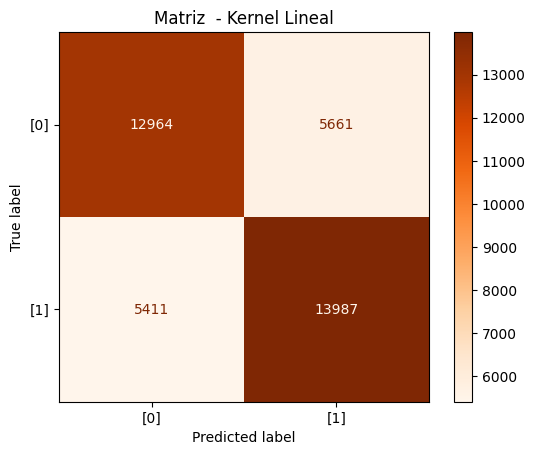

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

rep = classification_report(y_test, y_pred_kl)
print(rep)

cm = confusion_matrix(y_test, y_pred_kl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["[0]","[1]"])
disp.plot(cmap = "Oranges")
plt.title("Matriz  - Kernel Lineal")
plt.show()

# Redes Neuronales
El Perceptrón Multicapa es una red neuronal con capas ocultas capaz de aprender representaciones no lineales complejas. Su desempeño depende en gran medida de la arquitectura y los hiperparámetros. Requiere estandarización y puede ser propenso al sobreajuste si no se regulariza adecuadamente.

Se exploró una arquitectura más profunda (128, 64, 32) con early_stopping=True, obteniendo una exactitud de 0.744 frente a 0.744 de la arquitectura original (64, 32). La ausencia de mejora es lógica dado que en datos socioeconómicos, las redes neuronales profundas no necesariamente superan a arquitecturas más simples, ya que los datos no presentan la estructura jerárquica o secuencial que justifica capas adicionales.

Accuracy de Red Neuronal: 0.7437603555742577
F1-score de Red Neuronal: 0.7437574516958672
              precision    recall  f1-score   support

           0       0.73      0.76      0.74     18625
           1       0.76      0.73      0.74     19398

    accuracy                           0.74     38023
   macro avg       0.74      0.74      0.74     38023
weighted avg       0.74      0.74      0.74     38023



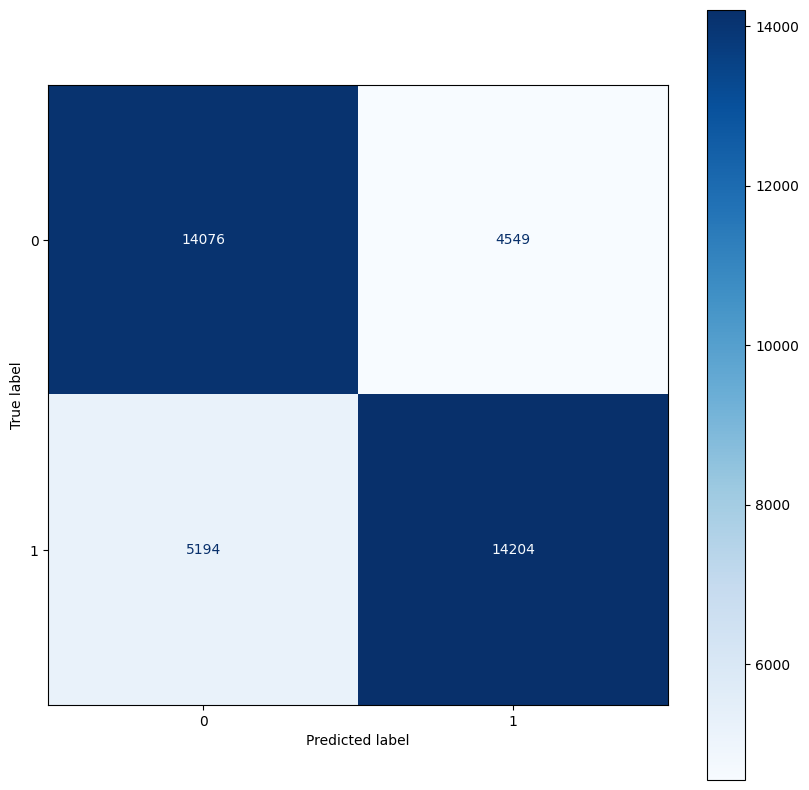

In [12]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
).fit(X_train_scaled, y_train)

predNN = nn.predict(X_test_scaled)
accNN = accuracy_score(y_test, predNN)
f1NN = f1_score(y_test, predNN, average="macro")
print("Accuracy de Red Neuronal:", accNN)
print("F1-score de Red Neuronal:", f1NN)
rep = classification_report(y_test, predNN)
print(rep)

disp = ConfusionMatrixDisplay.from_predictions(y_test, predNN, cmap=plt.cm.Blues)
fig = disp.ax_.get_figure()
fig.set_figwidth(10)
fig.set_figheight(10)

Accuracy de Red Neuronal: 0.7430239591826
F1-score de Red Neuronal: 0.742734231099089
              precision    recall  f1-score   support

           0       0.74      0.72      0.73     18625
           1       0.74      0.76      0.75     19398

    accuracy                           0.74     38023
   macro avg       0.74      0.74      0.74     38023
weighted avg       0.74      0.74      0.74     38023



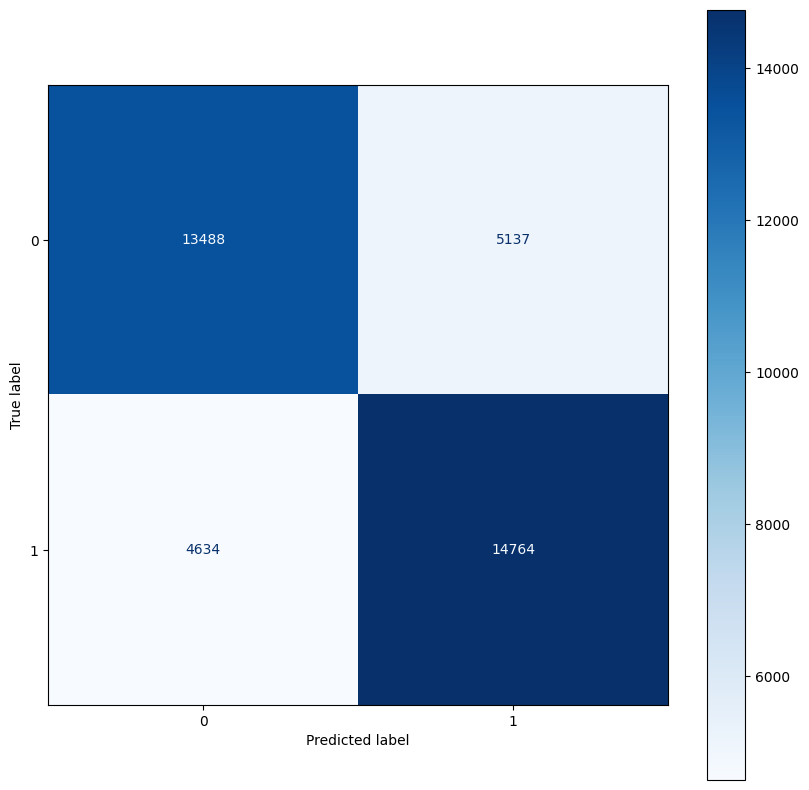

In [23]:
from sklearn.neural_network import MLPClassifier

nn_v2 = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), activation='relu',
    solver='adam', early_stopping=True,
    validation_fraction=0.1, max_iter=1000, random_state=42).fit(X_train_scaled, y_train)



predNN2 = nn_v2.predict(X_test_scaled)
accNN = accuracy_score(y_test, predNN2)
f1NN = f1_score(y_test, predNN2, average="macro")
print("Accuracy de Red Neuronal:", accNN)
print("F1-score de Red Neuronal:", f1NN)

rep = classification_report(y_test, predNN2)
print(rep)

disp = ConfusionMatrixDisplay.from_predictions(y_test, predNN2, cmap=plt.cm.Blues)
fig = disp.ax_.get_figure()
fig.set_figwidth(10)
fig.set_figheight(10)

# Selección del modelo final
Todos los modelos superan el clasificador aleatorio (AUC = 0.500), lo que confirma que las variables seleccionadas del conjunto contienen información predictiva relevante sobre el acceso a la seguridad social.
Boosting obtuvo el mejor AUC-ROC (0.844), seguido de cerca por la Red Neuronal (0.823). Ambos modelos no lineales superaron consistentemente a los modelos lineales (Regresión Logística, SVM y LDA), lo que sugiere que la relación entre las variables socioeconómicas y el acceso a seguridad social no es completamente lineal.
El LDA obtuvo el desempeño más bajo (0.709), lo cual es esperable dado que asume distribución normal multivariada e igual matriz de covarianza entre clases.

El modelo de boosting nos ayuda a tener mayor interpretabilidad de la problemática estudiada por su función de random features. Random features expone que características impactan más a las decisiones de los árboles .


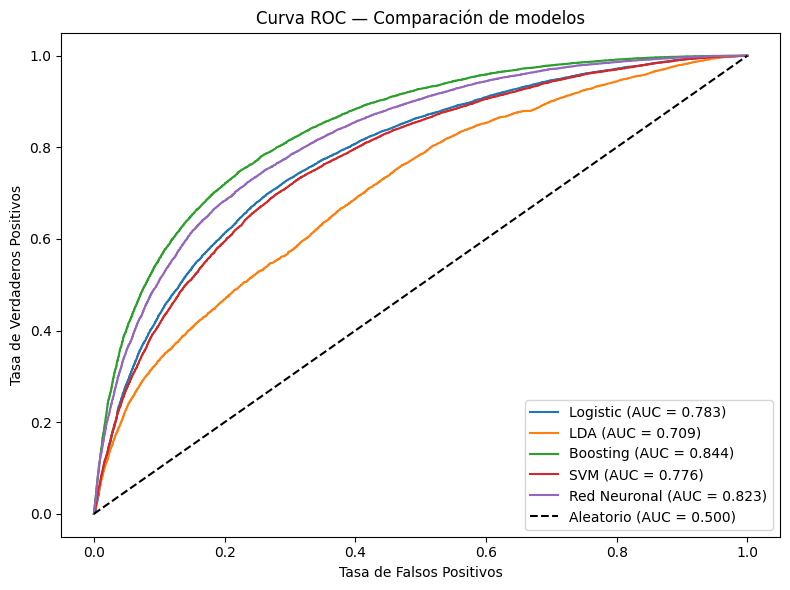

In [43]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilidades de cada modelo
prob_log = logreg_v2.predict_proba(X_test_scaled)[:, 1] # Use scaled test set for logreg
prob_lda = lda.predict_proba(X_test_lda_features_scaled)[:, 1] # Use unscaled test set for boost

prob_boost = boost_v2.predict_proba(X_test)[:, 1] # Use unscaled test set for boost
prob_svm = modelo_svm.predict_proba(X_test_scaled)[:, 1] # Use scaled test set for SVM
prob_nn    = nn_v2.predict_proba(X_test_scaled)[:, 1] # Use scaled test set for Neural Network

# Calcular curvas ROC
modelos = {
    'Logistic': prob_log,
    'LDA': prob_lda,
    'Boosting':      prob_boost,
    'SVM':           prob_svm,
    'Red Neuronal':  prob_nn
}

plt.figure(figsize=(8, 6))

for nombre, probs in modelos.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.500)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Comparación de modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluación del desempeño del modelo
Para la evalucación del modelo final, se tomarán en cuenta las siguientes métricas de desempeño:
1. **AUC-ROC promedio en validación cruzada**: Principal métrica de comparación.
2. **Reporte de clasificación**: Se toma en cuenta su accuracy, recall, F1-score y precision.
3. **Matriz de confusión**: Es importante visualizar la cantidad de datos acertados para cada clase.



   DESEMPEÑO EN CONJUNTO DE PRUEBA — BOOSTING
  AUC-ROC:   0.8437
  Exactitud: 0.7613

                     precision    recall  f1-score   support

Sin seg. social (0)       0.76      0.75      0.76     18625
Con seg. social (1)       0.76      0.77      0.77     19398

           accuracy                           0.76     38023
          macro avg       0.76      0.76      0.76     38023
       weighted avg       0.76      0.76      0.76     38023



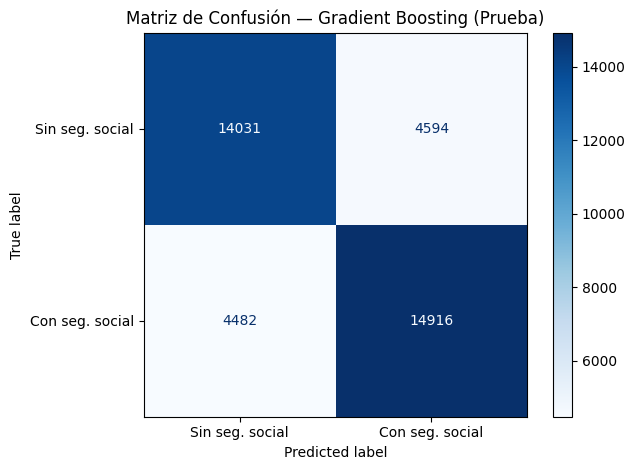

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# Predicciones del modelo final (Gradient Boosting)
y_pred_final = boost_v2.predict(X_test)
y_proba_final = boost_v2.predict_proba(X_test)[:, 1]

print("=" * 50)
print("   DESEMPEÑO EN CONJUNTO DE PRUEBA — BOOSTING")
print("=" * 50)
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_final):.4f}")
print(f"  Exactitud: {accuracy_score(y_test, y_pred_final):.4f}")
print()
print(classification_report(y_test, y_pred_final,
      target_names=['Sin seg. social (0)', 'Con seg. social (1)']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=['Sin seg. social', 'Con seg. social'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Gradient Boosting (Prueba)')
plt.tight_layout()
plt.show()

## Interpretación de Métricas — Gradient Boosting en Conjunto de Prueba

El modelo de Gradient Boosting alcanzó un **AUC-ROC de 0.844** y una **exactitud 
de 76.1%** sobre 38,023 personas del conjunto de prueba que el modelo nunca había visto.

**AUC-ROC (0.844):** En 84.4 de cada 100 comparaciones entre una persona con y sin 
seguridad social, el modelo asignó correctamente una probabilidad más alta a quien sí 
la tiene. Este valor supera el umbral de 0.80 considerado bueno en la práctica. 

**Exactitud (76.1%):** El modelo clasifica correctamente a aproximadamente 76%. Dado que las clases están relativamente balanceadas (49% sin seguro, 51% 
con seguro), esta métrica es confiable y no está inflada por el desbalance.

**Precisión (0.76 en ambas clases):** De cada 10 personas que el modelo predice *sin* 
seguridad social, aproximadamente 7-8 realmente carecen de ella. Esto limita las 
intervenciones innecesarias en políticas públicas.

**Recall (0.75 clase 0 / 0.77 clase 1):** El modelo detecta correctamente el 75% de 
las personas que realmente no tienen seguridad social. El restante son falsos 
negativos personas vulnerables que el modelo clasifica incorrectamente como 
aseguradas. En el contexto de focalización de programas sociales, este es el error 
más costoso, ya que podría excluir a quienes más necesitan apoyo.

**F1-Score (0.76):** El balance entre precisión y recall es simétrico en ambas clases, 
lo que confirma que el modelo no tiene sesgo sistemático hacia ninguna de las dos 
categorías.

## Conclusión y Reflexión Final

### Aprendizajes sobre la Problemática

El análisis realizado permitió identificar los factores más asociados con el acceso a la seguridad social en México. Variables como el ingreso total, la situación laboral y el nivel educativo emergen como los predictores más importantes, lo que confirma que la informalidad laboral y la desigualdad económica son los principales determinantes de la exclusión del sistema de seguridad social.

### Modelo Final

El modelo de Boosting resultó el más adecuado por las siguientes razones:
- Obtuvo el mayor AUC-ROC promedio en validación cruzada con baja varianza.
- No requiere supuestos paramétricos, siendo robusto ante relaciones no lineales entre variables.
- Ofrece importancia de variables, facilitando la interpretación de resultados en el contexto del problema.

### Limitaciones del Estudio

- **Problemas sociales**: Los problemas sociales son altamente complejos de interpretar, se obtuvieron mejores resultados a diferencia de los resultados de parcial pasado sin embargo aún quedan más variables interpretar para obtener un modelo más preciso.
- **Alta cantidad de datos**: Existen modelos que podrían capturar de mejor manera la naturaleza de comportamiento de los datos sin embargo, dado a la alta cantidad de datos, algunos modelos como SVM de Kernel RBF/Polinomial requiere de mucha complejidad computacional y no terminaban de procesar.
- **Variables no capturadas**: Factores como el tipo de contrato laboral, la región urbana/rural o el acceso a programas sociales no están directamente disponibles en las variables utilizadas.

### Extensiones Futuras

- Probar modelos que capturan modelos no lineales como por ejemplo diferentes Kernels SVM y probar QDA.
- Evaluar modelos más complejos en maquinas con mayor potencial computacional.
- Evaluar el impacto de variables de contexto del trabajo (utilizar 'trabajo.csv' en conjunto con poblacion.csv e ingresos.csv ) en la predicción.

## Opción de puntos extras
Tablero interactivo con uso del modelo seleccionado final para hacer predicciones si una persona cuenta con seguro social dependiendo sus características.
https://anapaolaloredo.github.io/IA.github.io/paginas_interactivas/predictor_segsoc.html


El modelo de Gradient Boosting fue exportado a formato JSON, serializando los 200
árboles de decisión con sus umbrales y valores hoja. El HTML carga este archivo y
reproduce la inferencia completa en JavaScript: recorre cada árbol con los valores
ingresados por el usuario, acumula las predicciones ponderadas por el learning rate
y aplica la función para obtener la probabilidad final.

In [44]:
import json
import numpy as np

def export_gbm_to_json(model, feature_names):
    """Exporta GradientBoostingClassifier a JSON para usarlo en JS"""
    from sklearn.tree import _tree

    def tree_to_dict(tree, feature_names):
        tree_ = tree.tree_

        def recurse(node):
            if tree_.feature[node] == _tree.TREE_UNDEFINED:
                # Hoja — retorna el valor
                return {"leaf": float(tree_.value[node][0][0])}
            else:
                return {
                    "feature": int(tree_.feature[node]),
                    "threshold": float(tree_.threshold[node]),
                    "left": recurse(tree_.children_left[node]),
                    "right": recurse(tree_.children_right[node])
                }
        return recurse(0)

    trees = []
    for estimator_group in model.estimators_:
        for estimator in estimator_group:
            trees.append(tree_to_dict(estimator, feature_names))

    export = {
        "learning_rate": model.learning_rate,
        "init_score": float(model._raw_predict_init(
            np.zeros((1, len(feature_names))))[0][0]),
        "n_estimators": model.n_estimators,
        "feature_names": list(feature_names),
        "trees": trees
    }

    with open("modelo_boost.json", "w") as f:
        json.dump(export, f)

    print(f"Modelo exportado: {len(trees)} árboles")
    print(f"Features: {len(feature_names)}")

# Exportar boost_v2
export_gbm_to_json(boost_v2, X_train.columns)

Modelo exportado: 200 árboles
Features: 23


# Referencias
**Uso de IA generativa para estética de gráficas y modelos.**
OpenAI. (2026). ChatGPT (modelo GPT-5.3) [Modelo de lenguaje de inteligencia artificial]. https://chat.openai.com/

**Uso de IA generativa para detección de errores y facilitamiento de código**
Anthropic. (2026). Claude [Modelo de lenguaje de inteligencia artificial]. https://www.anthropic.com/

**Fuentes de información del tema a tratar**

Bibliografía
Procuraduría Federal de la Defensa del Trabajo. (s/f). La seguridad social y sus beneficios. gob.mx. Recuperado el 24 de marzo de 2026, de https://www.gob.mx/profedet/articulos/seguridad-social

(S/f-a). Justia.com. Recuperado el 24 de marzo de 2026, de https://mexico.justia.com/derechos-humanos/derecho-a-la-seguridad-social/preguntas-y-respuestas-sobre-el-derecho-a-la-seguridad-social/

(S/f-b). Org.mx. Recuperado el 26 de marzo de 2026, de https://www.inegi.org.mx/contenidos/productos/prod_serv/contenidos/espanol/bvinegi/productos/nueva_estruc/889463910626.pdf